In [344]:
%pip install numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [345]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

In [346]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха
c_p = 1006

Предварительный расчет проточной части по средней линии тока

In [347]:
# Dk = const

d1_отн = 0.4    # Относительный диаметр втулки первой ступени
c_а1_отн = 0.45   # Коэффициент расхода первой ступени
с_а_отн = 0.3   # Коэффициент расхода для последней ступени примем
Hт_ср_отн = 0.3   # Коэффициент напора в средних ступенях
R_ср1 = 0.5   # Степень реактивности
H_т1 = 0.2   # Коэффициент напора первой ступени

# Первое приближение

In [348]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


In [349]:
# Определим адиабатический КПД
η_пол = 0.92 # Политропический КПД компрессора из рис.1
η_к_полн = ((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1)

# Пренебрегая теплообменом в трубках:
T1_полн = Tа_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = math.sqrt((2*k/(k+1))*R_в*Tа_полн)
a_кр_вых = math.sqrt((2*k/(k+1))*R_в*Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = Pа_полн / (Tа_полн * R_в)

# Окружная скорость конца рабочей лопатки
U_k1 = math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
print(f"U_k1 = {U_k1:.2f} м/с")

for i in range(3):      # Цикл для трех приближений
    # Осевая скорость на переферии РК
    c_а1 = c_а1_отн * U_k1

    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = U_k1 * c_а1_отн
    c_вых = U_k1 * с_а_отн

    # Приведенные скорости в данных сечениях
    λ_вх = c_вх / a_кр_вх
    λ_вых = c_вых / a_кр_вых

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = (1 - (k-1)/(k+1)*λ_вх**2)**(1/(k-1))
    ε_вых = (1 - (k-1)/(k+1)*λ_вых**2)**(1/(k-1))

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = 1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2)
    σ_вых = (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн

    # Средний радиус на входе в первую степень
    r_ср1_отн = math.sqrt( (1 + d1_отн**2) / 2)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = r_ср1_отн * (1 - R_ср1) - (H_т1 / (2 * r_ср1_отн))

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = c1 / a_кр_вх

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))

    # Плотность рабочего тела перед РК
    ρ1 = (P1_полн / (R_в * T1_полн)) * ε

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = math.cbrt((G_в * n**2)/(math.pi * c_а1_отн * ρ1 * (1 - d1_отн**2)))
    print(f" u = {U_k1}")

U_k1 = 319.97 м/с
 u = 333.63450245775124
 u = 334.87940394444325
 u = 334.99584567148423


In [350]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = U_k1 * c_а1_отн
c_вых = U_k1 * с_а_отн

# Приведенные скорости в данных сечениях
λ_вх = c_вх / a_кр_вх
λ_вых = c_вых / a_кр_вых

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = (1 - (k-1)/(k+1)*λ_вх**2)**(1/(k-1))
ε_вых = (1 - (k-1)/(k+1)*λ_вых**2)**(1/(k-1))

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = 1 / (1 + ξ_вх * (k/(k+1)) * ε_вх * λ_вх**2)
σ_вых = (1 - ξ_вых * (k/(k+1)) * ε_вых * λ_вых**2)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = math.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))

# Приведенная плотность потока массы
q_вх = ((k+1)/2)**(1/(k-1)) * λ_вх * (1 - (k-1)/(k+1)*λ_вх**2)**(1/(k-1))
q_вых = ((k+1)/2)**(1/(k-1)) * λ_вых * (1 - (k-1)/(k+1)*λ_вых**2)**(1/(k-1))
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = (G_в * math.sqrt(R_в * T1_полн)) / (β * P1_полн * q_вх)
F_вых = (G_в * math.sqrt(R_в * T2_полн)) / (β * P2_полн * q_вых)

# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

# Диаметр втулки лопаток последнйей ступени:
D_вт_n = math.sqrt(D_к1**2 - ((4 * F_вых) / math.pi))

# Относительный диаметр втулки рабочего колеса последней ступени:
d_n_отн = D_вт_n / D_к1

# Высота лопаток последней ступени:
h_n = (1/2) * D_к1 * (1 - d_n_отн)

# Окружная скорость концов рабочих лопаток "средней" ступени:
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_k1**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
print(f"z = {z} Не округленное")

z = math.ceil(z)
print(f"z = {z}")

z = 12.392299547954384 Не округленное
z = 13


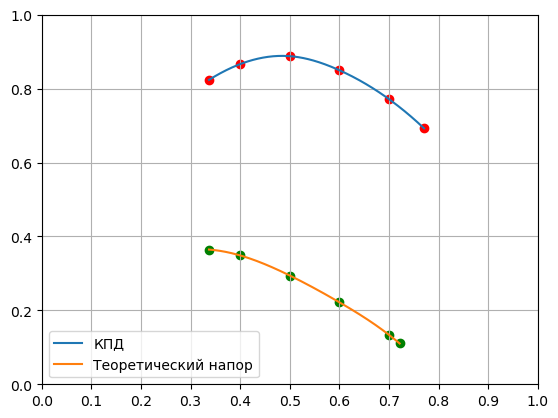

In [351]:
# Ваши точки
x = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])
y = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])

x1 = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])
y1 = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721])

# Создаем более плотную сетку X для плавности
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=3) # k=3 — кубический сплайн
y_smooth = spline(x_smooth)

x1_smooth = np.linspace(x1.min(), x1.max(), 300)
spline = make_interp_spline(x1, y1, k=3) # k=3 — кубический сплайн
y1_smooth = spline(x1_smooth)

plt.plot(x_smooth, y_smooth, label='КПД')
plt.scatter(x, y, color='red')
plt.plot(x1_smooth, y1_smooth, label='Теоретический напор')
plt.scatter(x1, y1, color='green')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()


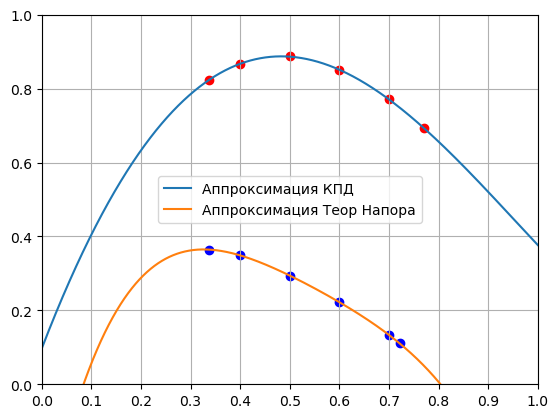

In [352]:
# Ваши точки
x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])
Hт_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])

x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])
η_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721])

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

In [353]:
Hт_x_line = x_Hт_dots_smooth
Hт_y_line = Hт_dots_smooth
η_x_line = x_η_dots_smooth
η_y_line = η_dots_smooth

N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)

Hт_x_result = []
Hт_отн_result = []

c_a_отн = np.linspace(c_а1_отн, с_а_отн, N)
print(c_a_отн)

[0.45   0.4375 0.425  0.4125 0.4    0.3875 0.375  0.3625 0.35   0.3375
 0.325  0.3125 0.3   ]


In [354]:
def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_отн)):
        index = np.abs(x_line - c_a_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
        print(f"index = {index}, (иск. x) = {c_a_отн[i]:.4f}, (найд. x) = {x_line[index]:.4f}, (найд. y) = {y_line[index]:.4f}")
    print("Конец расчётов","\n")
    return x_result, y_result

Hт_x_result, Hт_отн_result = find_nearest(c_a_отн, Hт_x_line, Hт_y_line)
η_x_result, η_отн_result = find_nearest(c_a_отн, η_x_line, η_y_line)

index = 45000, (иск. x) = 0.4500, (найд. x) = 0.4500, (найд. y) = 0.8842
index = 43750, (иск. x) = 0.4375, (найд. x) = 0.4375, (найд. y) = 0.8814
index = 42500, (иск. x) = 0.4250, (найд. x) = 0.4250, (найд. y) = 0.8776
index = 41250, (иск. x) = 0.4125, (найд. x) = 0.4125, (найд. y) = 0.8729
index = 40000, (иск. x) = 0.4000, (найд. x) = 0.4000, (найд. y) = 0.8673
index = 38750, (иск. x) = 0.3875, (найд. x) = 0.3875, (найд. y) = 0.8606
index = 37500, (иск. x) = 0.3750, (найд. x) = 0.3750, (найд. y) = 0.8529
index = 36250, (иск. x) = 0.3625, (найд. x) = 0.3625, (найд. y) = 0.8443
index = 35000, (иск. x) = 0.3500, (найд. x) = 0.3500, (найд. y) = 0.8346
index = 33750, (иск. x) = 0.3375, (найд. x) = 0.3375, (найд. y) = 0.8238
index = 32500, (иск. x) = 0.3250, (найд. x) = 0.3250, (найд. y) = 0.8120
index = 31250, (иск. x) = 0.3125, (найд. x) = 0.3125, (найд. y) = 0.7991
index = 30000, (иск. x) = 0.3000, (найд. x) = 0.3000, (найд. y) = 0.7852
Конец расчётов 

index = 45000, (иск. x) = 0.4500, 

In [355]:
c_a_отн

array([0.45  , 0.4375, 0.425 , 0.4125, 0.4   , 0.3875, 0.375 , 0.3625,
       0.35  , 0.3375, 0.325 , 0.3125, 0.3   ])

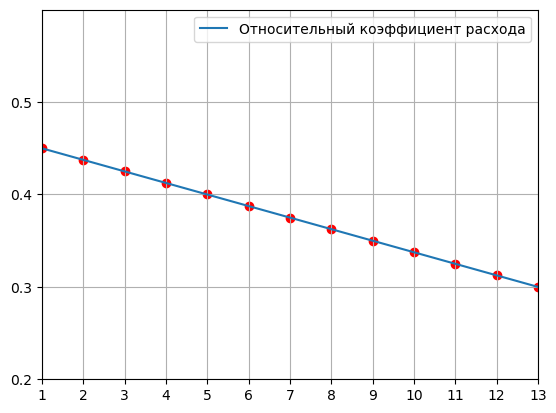

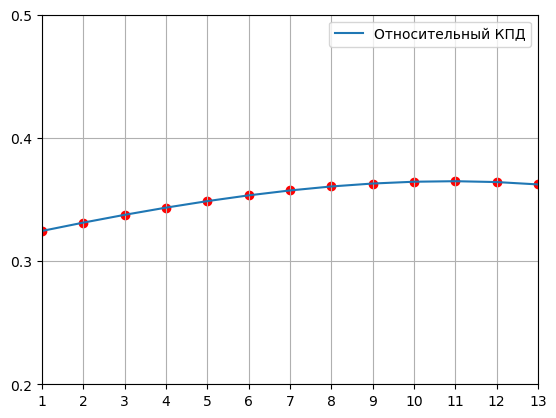

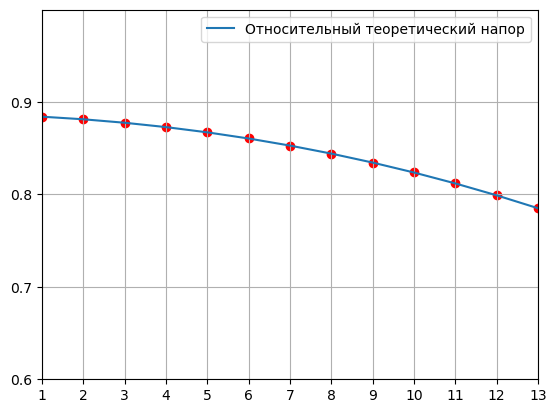

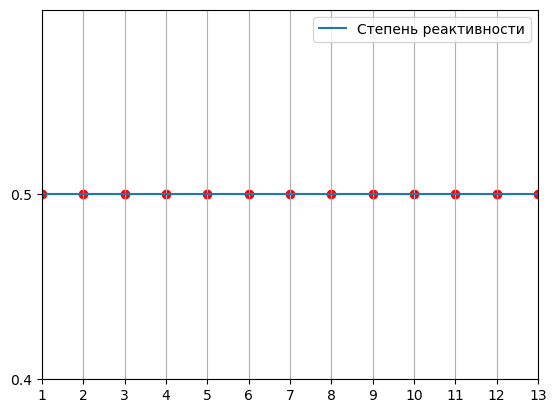

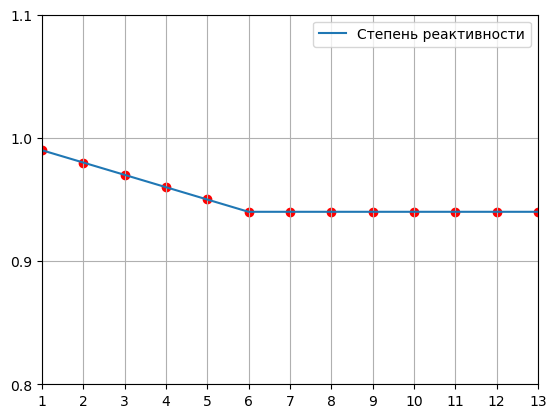

In [ ]:
def plot_results(x, y, label_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()

R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_отн, "Относительный коэффициент расхода")
plot_results(N_list, η_отн_result, "Относительный КПД")
plot_results(N_list, Hт_отн_result, "Относительный теоретический напор")
plot_results(N_list, R_ср1_list, "Степень реактивности")
plot_results(N_list, Kh, "Поправочный коэффициент")